# Missão Aurora Siger — Sistema de Verificação de Pré-Decolagem

**Disciplina:** Ciência da Computação — Fase 1 | FIAP 2026  
**Atividade:** Relatório Operacional de Pré-Decolagem  
**Aluno:** Erik Appe  


Este notebook implementa um sistema de verificação de telemetria para a missão Aurora Siger, nave fictícia com destino a Marte. Os dados utilizados são baseados em fontes reais da NASA (ISS) e SpaceX (Falcon 9), adaptados ao contexto da atividade.

---

## Sumário
1. [Telemetria Inicial](#telemetria)
2. [Algoritmo de Verificação](#algoritmo)
3. [Simulação de Anomalia](#anomalia)
4. [Análise Energética](#energia)
5. [Análise Assistida por IA](#ia)
6. [Reflexão Crítica](#reflexao)
7. [Relatório Final](#relatorio)

In [1]:
# Importações
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime

print('Bibliotecas carregadas.')
print('Data/Hora da verificação:', datetime.now().strftime('%d/%m/%Y %H:%M:%S'))

Bibliotecas carregadas.
Data/Hora da verificação: 18/03/2026 10:30:05


---

## 1. Organização e Descrição da Telemetria <a id='telemetria'></a>

Os dados abaixo representam a telemetria da Aurora Siger no momento T-60 minutos antes da decolagem. Cada parâmetro foi definido com base em fontes reais, conforme a tabela de referência abaixo.

| Parâmetro | Fonte Real |
|-----------|------------|
| Temperatura interna | ISS mantém entre 18 e 27 °C nos módulos habitáveis |
| Temperatura externa | Em órbita baixa: varia de -120 °C a +120 °C |
| Pressão tanque LOX | Falcon 9 opera entre 40 e 55 psi |
| Temperatura LOX | SpaceX sub-resfria o oxigênio a -207 °C (66 K) |
| Integridade estrutural | Binário: 1 = íntegro, 0 = falha detectada |
| Nível de energia | ISS opera com reserva mínima de 75% |
| Status módulos críticos | Binário: 1 = todos operacionais, 0 = falha |

In [2]:
# Carregando os dados de telemetria a partir do arquivo CSV
df_csv = pd.read_csv('telemetria.csv')

# Extraindo o cenário nominal
linha_nominal = df_csv[df_csv['cenario'] == 'NOMINAL'].iloc[0]

telemetria = {
    'temp_interna':   int(linha_nominal['temp_interna']),
    'temp_externa':   int(linha_nominal['temp_externa']),
    'pressao_lox':    int(linha_nominal['pressao_lox']),
    'temp_lox':       int(linha_nominal['temp_lox']),
    'integridade':    int(linha_nominal['integridade']),
    'nivel_energia':  int(linha_nominal['nivel_energia']),
    'status_modulos': int(linha_nominal['status_modulos']),
}

# Faixas seguras definidas com base em dados reais
faixas = {
    'temp_interna':   (18,   27),
    'temp_externa':  (-120, 120),
    'pressao_lox':    (40,   55),
    'temp_lox':      (-215, -200),
    'integridade':    (1,     1),
    'nivel_energia':  (75,  100),
    'status_modulos': (1,     1),
}

unidades = {
    'temp_interna':   'C',
    'temp_externa':   'C',
    'pressao_lox':    'psi',
    'temp_lox':       'C',
    'integridade':    '(0/1)',
    'nivel_energia':  '%',
    'status_modulos': '(0/1)',
}

fontes = {
    'temp_interna':   'NASA ISS',
    'temp_externa':   'NASA ISS / SpaceX',
    'pressao_lox':    'SpaceX Falcon 9',
    'temp_lox':       'SpaceX Falcon 9',
    'integridade':    'NASA / SpaceX',
    'nivel_energia':  'NASA ISS',
    'status_modulos': 'NASA / SpaceX',
}

nomes = {
    'temp_interna':   'Temperatura Interna',
    'temp_externa':   'Temperatura Externa',
    'pressao_lox':    'Pressao Tanque LOX',
    'temp_lox':       'Temperatura do LOX',
    'integridade':    'Integridade Estrutural',
    'nivel_energia':  'Nivel de Energia',
    'status_modulos': 'Status Modulos Criticos',
}

# Montar tabela de telemetria
registros = []
for param, valor in telemetria.items():
    fmin, fmax = faixas[param]
    if param in ('integridade', 'status_modulos'):
        status = 'OK' if valor == 1 else 'ALERTA'
        faixa_str = '= 1'
    else:
        status = 'OK' if fmin <= valor <= fmax else 'ALERTA'
        faixa_str = f'{fmin} a {fmax}'

    registros.append({
        'Parametro':    nomes[param],
        'Valor Atual':  f'{valor} {unidades[param]}',
        'Faixa Segura': f'{faixa_str} {unidades[param]}',
        'Fonte Real':   fontes[param],
        'Status':       status,
    })

df_telemetria = pd.DataFrame(registros)

def colorir_linha(row):
    if row['Status'] == 'ALERTA':
        return ['background-color: #ffcccc'] * len(row)
    return ['background-color: #ccffcc'] * len(row)

print('Telemetria carregada de telemetria.csv — cenario NOMINAL')
print(f'Arquivo: telemetria.csv | Linhas: {len(df_csv)} | Parametros: {len(telemetria)}')
df_telemetria.style.apply(colorir_linha, axis=1)

Telemetria carregada de telemetria.csv — cenario NOMINAL
Arquivo: telemetria.csv | Linhas: 2 | Parametros: 7


,Parametro,Valor Atual,Faixa Segura,Fonte Real,Status
0,Temperatura Interna,22 C,18 a 27 C,NASA ISS,OK
1,Temperatura Externa,-85 C,-120 a 120 C,NASA ISS / SpaceX,OK
2,Pressao Tanque LOX,47 psi,40 a 55 psi,SpaceX Falcon 9,OK
3,Temperatura do LOX,-207 C,-215 a -200 C,SpaceX Falcon 9,OK
4,Integridade Estrutural,1 (0/1),= 1 (0/1),NASA / SpaceX,OK
5,Nivel de Energia,87 %,75 a 100 %,NASA ISS,OK
6,Status Modulos Criticos,1 (0/1),= 1 (0/1),NASA / SpaceX,OK


---

## 2. Algoritmo de Verificação <a id='algoritmo'></a>

O algoritmo percorre cada parâmetro de telemetria e verifica se está dentro da faixa segura definida. Ao final, emite a decisão operacional. O pseudocódigo abaixo descreve a lógica implementada:

```
INICIO
  pronto_para_decolar <- VERDADEIRO
  alertas <- []

  PARA CADA parametro EM telemetria FACA
    SE parametro e binario (integridade, status_modulos)
      SE valor != 1 ENTAO
        pronto_para_decolar <- FALSO
        ADICIONAR alerta critico em alertas
    SENAO
      SE valor < minimo OU valor > maximo ENTAO
        pronto_para_decolar <- FALSO
        ADICIONAR alerta em alertas
  FIM PARA

  SE pronto_para_decolar = VERDADEIRO
    IMPRIMIR "PRONTO PARA DECOLAR"
  SENAO
    IMPRIMIR alertas
    IMPRIMIR "DECOLAGEM ABORTADA"
FIM
```

In [3]:
# Função de verificação de telemetria

def verificar_telemetria(telemetria_dados, faixas_seguras, rotulo='CENARIO'):
    '''
    Verifica cada parametro de telemetria contra as faixas seguras.
    Retorna: (pronto_para_decolar: bool, alertas: list)
    '''
    pronto_para_decolar = True
    alertas = []

    print(f'Verificacao de telemetria — {rotulo}')
    print('-' * 55)

    for param, valor in telemetria_dados.items():
        fmin, fmax = faixas_seguras[param]
        nome = nomes[param]

        if param in ('integridade', 'status_modulos'):
            if valor != 1:
                pronto_para_decolar = False
                msg = f'ALERTA CRITICO: {nome} — falha detectada (valor={valor})'
                alertas.append(msg)
                print(f'  FALHA  | {nome}: {valor} — deve ser 1')
            else:
                print(f'  OK     | {nome}: {valor}')
        else:
            if not (fmin <= valor <= fmax):
                pronto_para_decolar = False
                msg = f'ALERTA: {nome} fora da faixa ({fmin} a {fmax} {unidades[param]}). Valor: {valor}'
                alertas.append(msg)
                print(f'  FALHA  | {nome}: {valor} {unidades[param]} — fora da faixa [{fmin}, {fmax}]')
            else:
                print(f'  OK     | {nome}: {valor} {unidades[param]} (faixa: {fmin} a {fmax})')

    return pronto_para_decolar, alertas


def exibir_resultado(pronto, alertas):
    print('-' * 55)
    if alertas:
        print('\nAlertas registrados:')
        for alerta in alertas:
            print(f'  - {alerta}')
    print('-' * 55)
    if pronto:
        print('RESULTADO: PRONTO PARA DECOLAR — todos os sistemas operacionais.')
    else:
        print('RESULTADO: DECOLAGEM ABORTADA — corrija os alertas antes de prosseguir.')
    print('-' * 55)

print('Funcao verificar_telemetria() carregada.')

Funcao verificar_telemetria() carregada.


In [4]:
# Execução — Cenário Normal (todos os sistemas dentro da faixa)

pronto_normal, alertas_normal = verificar_telemetria(
    telemetria, faixas, rotulo='Telemetria Normal — Aurora Siger'
)
exibir_resultado(pronto_normal, alertas_normal)

Verificacao de telemetria — Telemetria Normal — Aurora Siger
-------------------------------------------------------
  OK     | Temperatura Interna: 22 C (faixa: 18 a 27)
  OK     | Temperatura Externa: -85 C (faixa: -120 a 120)
  OK     | Pressao Tanque LOX: 47 psi (faixa: 40 a 55)
  OK     | Temperatura do LOX: -207 C (faixa: -215 a -200)
  OK     | Integridade Estrutural: 1
  OK     | Nivel de Energia: 87 % (faixa: 75 a 100)
  OK     | Status Modulos Criticos: 1
-------------------------------------------------------
-------------------------------------------------------
RESULTADO: PRONTO PARA DECOLAR — todos os sistemas operacionais.
-------------------------------------------------------


---

## 3. Simulação de Anomalia <a id='anomalia'></a>

Para testar a robustez do sistema, foram inseridas falhas propositais em quatro parâmetros:

| Parâmetro | Valor Normal | Valor de Falha | Motivo |
|-----------|-------------|----------------|--------|
| Temperatura Interna | 22 C | 35 C | Acima do limite máximo de 27 C |
| Pressão Tanque LOX | 47 psi | 30 psi | Abaixo do limite mínimo de 40 psi |
| Integridade Estrutural | 1 | 0 | Falha crítica detectada |
| Nível de Energia | 87% | 60% | Abaixo do mínimo operacional de 75% |

In [5]:
# Carregando o cenário de falha a partir do CSV
linha_falha = df_csv[df_csv['cenario'] == 'FALHA_SIMULADA'].iloc[0]

telemetria_falha = {
    'temp_interna':   int(linha_falha['temp_interna']),
    'temp_externa':   int(linha_falha['temp_externa']),
    'pressao_lox':    int(linha_falha['pressao_lox']),
    'temp_lox':       int(linha_falha['temp_lox']),
    'integridade':    int(linha_falha['integridade']),
    'nivel_energia':  int(linha_falha['nivel_energia']),
    'status_modulos': int(linha_falha['status_modulos']),
}

print('Cenario de falha carregado de telemetria.csv')
pronto_falha, alertas_falha = verificar_telemetria(
    telemetria_falha, faixas, rotulo='Simulacao de Anomalia'
)
exibir_resultado(pronto_falha, alertas_falha)

Cenario de falha carregado de telemetria.csv
Verificacao de telemetria — Simulacao de Anomalia
-------------------------------------------------------
  FALHA  | Temperatura Interna: 35 C — fora da faixa [18, 27]
  OK     | Temperatura Externa: -85 C (faixa: -120 a 120)
  FALHA  | Pressao Tanque LOX: 30 psi — fora da faixa [40, 55]
  OK     | Temperatura do LOX: -207 C (faixa: -215 a -200)
  FALHA  | Integridade Estrutural: 0 — deve ser 1
  FALHA  | Nivel de Energia: 60 % — fora da faixa [75, 100]
  OK     | Status Modulos Criticos: 1
-------------------------------------------------------

Alertas registrados:
  - ALERTA: Temperatura Interna fora da faixa (18 a 27 C). Valor: 35
  - ALERTA: Pressao Tanque LOX fora da faixa (40 a 55 psi). Valor: 30
  - ALERTA CRITICO: Integridade Estrutural — falha detectada (valor=0)
  - ALERTA: Nivel de Energia fora da faixa (75 a 100 %). Valor: 60
-------------------------------------------------------
RESULTADO: DECOLAGEM ABORTADA — corrija os alert

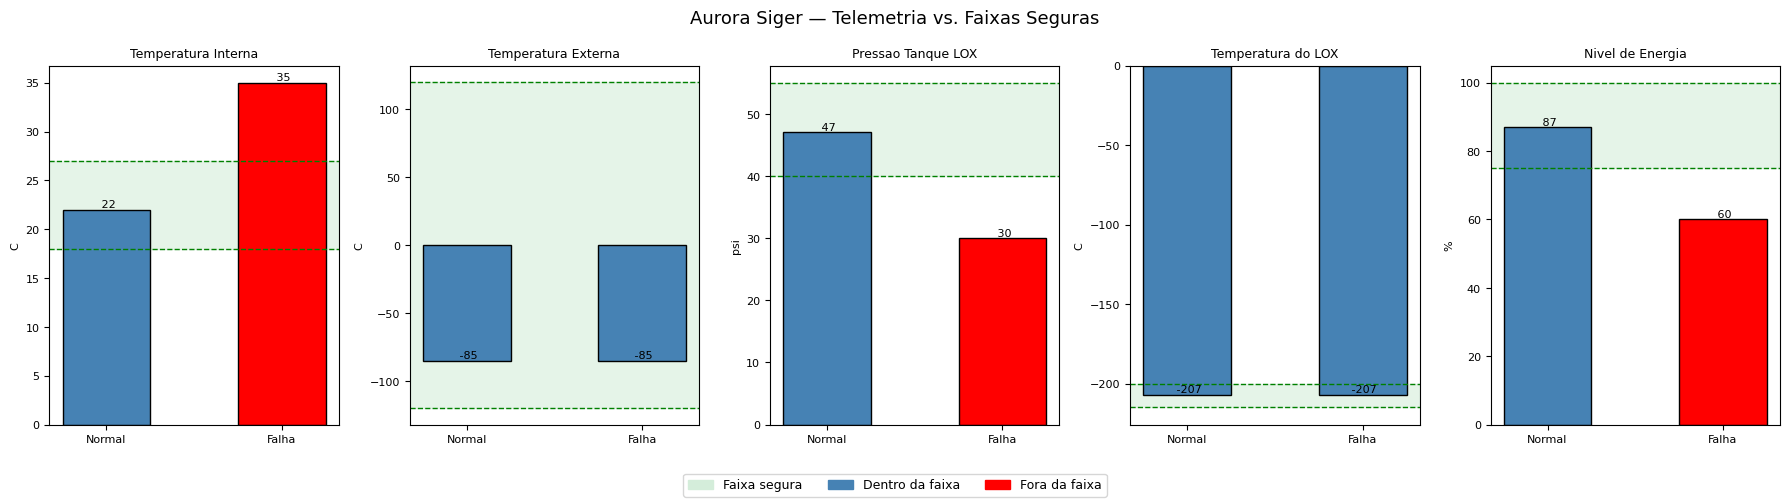

In [6]:
# Gráfico — Telemetria atual vs. faixas seguras

params_graf = ['temp_interna', 'temp_externa', 'pressao_lox', 'temp_lox', 'nivel_energia']

fig, axes = plt.subplots(1, len(params_graf), figsize=(18, 5))
fig.suptitle('Aurora Siger — Telemetria vs. Faixas Seguras', fontsize=13)

for i, param in enumerate(params_graf):
    ax = axes[i]
    fmin, fmax = faixas[param]
    valor_normal = telemetria[param]
    valor_falha  = telemetria_falha[param]

    ax.axhspan(fmin, fmax, color='#d4edda', alpha=0.6)
    ax.axhline(fmin, color='green', linestyle='--', linewidth=1)
    ax.axhline(fmax, color='green', linestyle='--', linewidth=1)

    cor_n = 'steelblue' if fmin <= valor_normal <= fmax else 'red'
    cor_f = 'steelblue' if fmin <= valor_falha  <= fmax else 'red'

    ax.bar(['Normal', 'Falha'], [valor_normal, valor_falha],
           color=[cor_n, cor_f], width=0.5, edgecolor='black')

    ax.set_title(nomes[param], fontsize=9)
    ax.set_ylabel(unidades[param], fontsize=8)
    ax.tick_params(labelsize=8)
    ax.text(0, valor_normal, f' {valor_normal}', va='bottom', ha='center', fontsize=8)
    ax.text(1, valor_falha,  f' {valor_falha}',  va='bottom', ha='center', fontsize=8)

patch_safe = mpatches.Patch(color='#d4edda', label='Faixa segura')
patch_ok   = mpatches.Patch(color='steelblue', label='Dentro da faixa')
patch_alrt = mpatches.Patch(color='red', label='Fora da faixa')
fig.legend(handles=[patch_safe, patch_ok, patch_alrt], loc='lower center', ncol=3, fontsize=9)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('telemetria_grafico.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. Análise Energética <a id='energia'></a>

O cálculo abaixo determina a autonomia energética da Aurora Siger antes da decolagem, com base no sistema de baterias de íons de lítio da ISS (capacidade de 192 kWh).

Dados de entrada:
- Capacidade total das baterias: 192 kWh (referência: NASA ISS)
- Carga atual: 87% (valor da telemetria)
- Consumo estimado na decolagem: 120 kWh (ISS usa entre 75 e 90 kW/h — estimativa conservadora)
- Perdas energéticas estimadas: 5% (calor e conversão elétrica)

Analise Energetica — Aurora Siger
--------------------------------------------------
  Capacidade total           : 192.0 kWh
  Carga atual                : 87%
  Energia disponivel         : 167.04 kWh
  Perdas (5%)              : -8.35 kWh
  Energia efetiva            : 158.69 kWh
  Consumo na decolagem       : -120.0 kWh
  Energia residual           : 38.69 kWh  (20.1%)
  Autonomia residual         : 0.5 horas
--------------------------------------------------
  Diagnostico: energia residual baixa — monitoramento recomendado.


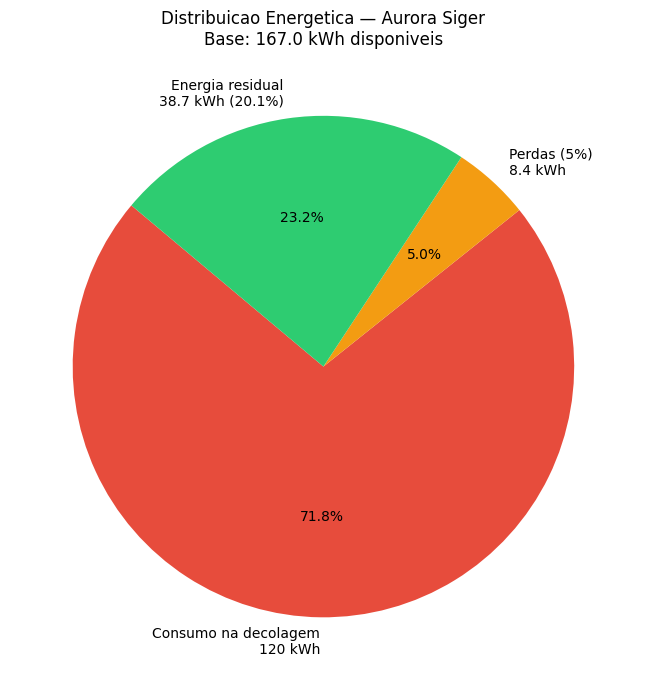

In [7]:
# Análise energética

capacidade_total_kwh  = 192
carga_atual_pct       = 87
consumo_decolagem_kwh = 120
perda_pct             = 5

energia_disponivel = capacidade_total_kwh * (carga_atual_pct / 100)
perda_kwh          = energia_disponivel * (perda_pct / 100)
energia_efetiva    = energia_disponivel - perda_kwh
energia_residual   = energia_efetiva - consumo_decolagem_kwh
residual_pct       = (energia_residual / capacidade_total_kwh) * 100
autonomia_horas    = energia_residual / 82.5  # consumo medio da ISS: 82,5 kW

print('Analise Energetica — Aurora Siger')
print('-' * 50)
print(f'  Capacidade total           : {capacidade_total_kwh:.1f} kWh')
print(f'  Carga atual                : {carga_atual_pct}%')
print(f'  Energia disponivel         : {energia_disponivel:.2f} kWh')
print(f'  Perdas ({perda_pct}%)              : -{perda_kwh:.2f} kWh')
print(f'  Energia efetiva            : {energia_efetiva:.2f} kWh')
print(f'  Consumo na decolagem       : -{consumo_decolagem_kwh:.1f} kWh')
print(f'  Energia residual           : {energia_residual:.2f} kWh  ({residual_pct:.1f}%)')
print(f'  Autonomia residual         : {autonomia_horas:.1f} horas')
print('-' * 50)

if residual_pct >= 30:
    print('  Diagnostico: energia suficiente para a decolagem.')
elif residual_pct >= 15:
    print('  Diagnostico: energia residual baixa — monitoramento recomendado.')
else:
    print('  Diagnostico: energia insuficiente — recarregar antes da decolagem.')

# Grafico de distribuicao energetica
fig2, ax2 = plt.subplots(figsize=(7, 7))
valores = [consumo_decolagem_kwh, perda_kwh, energia_residual]
rotulos = [
    f'Consumo na decolagem\n{consumo_decolagem_kwh} kWh',
    f'Perdas ({perda_pct}%)\n{perda_kwh:.1f} kWh',
    f'Energia residual\n{energia_residual:.1f} kWh ({residual_pct:.1f}%)',
]
cores = ['#e74c3c', '#f39c12', '#2ecc71']

ax2.pie(valores, labels=rotulos, colors=cores, autopct='%1.1f%%',
        startangle=140, textprops={'fontsize': 10})
ax2.set_title(
    f'Distribuicao Energetica — Aurora Siger\n'
    f'Base: {energia_disponivel:.1f} kWh disponiveis',
    fontsize=12
)
plt.tight_layout()
plt.savefig('energia_grafico.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 5. Análise Assistida por IA <a id='ia'></a>

**Ferramenta utilizada:** Claude (Anthropic) — Data: 16/03/2026  

Os dados de telemetria foram submetidos a uma ferramenta de IA para classificação do estado operacional, identificação de possíveis anomalias e sugestões preventivas antes da decolagem.

**Classificação geral:** todos os 7 parâmetros estão dentro das faixas operacionais seguras. Estado da nave: OPERACIONAL.

**Pontos de atenção identificados:**

1. A energia residual estimada pós-decolagem (em torno de 20%) está próxima do limite mínimo recomendado. O risco é considerado médio, com monitoramento contínuo da bateria recomendado após a decolagem.

2. A temperatura do LOX a -207 C está próxima do limite superior da faixa segura (-200 C). Uma variação de +7 C já acionaria o alerta. O risco é baixo, mas recomenda-se verificar o sistema de refrigeração antes da decolagem.

3. A temperatura externa de -85 C apresenta margem adequada, mas variações de ±35 C são normais em órbita durante transições claro/escuro. O sistema de controle térmico deve permanecer ativo.

**Sugestões operacionais:**

- Monitorar o nível de energia a cada 10 minutos durante a fase de decolagem
- Verificar o sistema de refrigeração do LOX antes de T-30 minutos
- Manter o controle térmico externo ativo durante todo o lançamento
- Realizar nova leitura de telemetria em T-15 minutos para confirmar todos os parâmetros

---

## 6. Reflexão Crítica <a id='reflexao'></a>

### Ética e responsabilidade

Trabalhar com sistemas de verificação para missões espaciais torna evidente o quanto a programação pode ter consequências reais e sérias. Um parâmetro mal definido, uma condição lógica errada ou uma verificação esquecida pode comprometer toda uma missão — e, em contextos reais, colocar vidas em risco. Isso muda completamente a forma como se pensa o código: não é só fazer funcionar, é garantir que funciona em todos os cenários possíveis, inclusive nos piores. A responsabilidade do desenvolvedor nesses contextos vai muito além de entregar um programa que roda sem erros.

### Impacto social da exploração espacial

A exploração espacial é um campo que mistura avanço científico genuíno com questões sociais e políticas complexas. Por um lado, tecnologias desenvolvidas para missões espaciais chegam a aplicações cotidianas em medicina, comunicações e monitoramento ambiental. Por outro, envolve investimentos enormes que poderiam ser direcionados a problemas imediatos na Terra. Não existe uma resposta simples para esse dilema, mas ele precisa ser considerado. O acesso aos benefícios das descobertas espaciais também não é distribuído de forma igual entre países e populações.

### Sustentabilidade tecnológica

Cada lançamento espacial consome recursos e gera emissões. O lixo orbital é um problema crescente: fragmentos de foguetes e satélites inativos representam risco real para novas missões. A reutilização de componentes, como praticada pelo Falcon 9, é um avanço, mas não resolve o problema por completo. A sustentabilidade na exploração espacial vai exigir regulamentação internacional, padrões mais rigorosos e uma mudança de mentalidade sobre o que significa "progresso" nessa área.

### Conclusão

Desenvolver esse projeto foi uma forma concreta de perceber como computação, física, energia e ética se conectam em situações reais. O código que escrevemos aqui simula decisões que equipes da NASA e SpaceX precisam tomar com alta precisão. Pensar nisso enquanto programava trouxe uma perspectiva diferente sobre o que significa escrever um bom sistema — não apenas funcional, mas confiável, documentado e responsável.

In [8]:
# Relatório final consolidado

agora = datetime.now().strftime('%d/%m/%Y %H:%M:%S')

print('=' * 60)
print('   RELATORIO OPERACIONAL DE PRE-DECOLAGEM')
print('   Missao Aurora Siger')
print('=' * 60)
print(f'  Data/Hora         : {agora}')
print(f'  Responsavel       : Erik Appe')
print(f'  Disciplina        : Ciencia da Computacao — Fase 1')
print(f'  Instituicao       : FIAP 2026')
print('=' * 60)

print('\nVERIFICACAO DE TELEMETRIA')
total = len(telemetria)
ok = sum(
    1 for p, v in telemetria.items()
    if (v == 1 if p in ('integridade', 'status_modulos') else faixas[p][0] <= v <= faixas[p][1])
)
print(f'  Parametros verificados : {total}')
print(f'  Dentro da faixa        : {ok}')
print(f'  Em alerta              : {total - ok}')
print(f'  Decisao                : {"PRONTO PARA DECOLAR" if pronto_normal else "DECOLAGEM ABORTADA"}')

print('\nANALISE ENERGETICA')
print(f'  Energia disponivel     : {energia_disponivel:.2f} kWh')
print(f'  Energia pos-decolagem  : {energia_residual:.2f} kWh ({residual_pct:.1f}%)')
print(f'  Autonomia residual     : {autonomia_horas:.1f} horas')

print('\nCLASSIFICACAO DA IA')
print('  Estado geral           : OPERACIONAL')
print('  Anomalias criticas     : nenhuma')
print('  Pontos de atencao      : 2 (energia residual e temperatura do LOX)')

print('\n' + '=' * 60)
print(f'  STATUS FINAL: {"PRONTO PARA DECOLAR" if pronto_normal else "DECOLAGEM ABORTADA"}')
print('=' * 60)

   RELATORIO OPERACIONAL DE PRE-DECOLAGEM
   Missao Aurora Siger
  Data/Hora         : 18/03/2026 10:30:10
  Responsavel       : Erik Appe
  Disciplina        : Ciencia da Computacao — Fase 1
  Instituicao       : FIAP 2026

VERIFICACAO DE TELEMETRIA
  Parametros verificados : 7
  Dentro da faixa        : 7
  Em alerta              : 0
  Decisao                : PRONTO PARA DECOLAR

ANALISE ENERGETICA
  Energia disponivel     : 167.04 kWh
  Energia pos-decolagem  : 38.69 kWh (20.1%)
  Autonomia residual     : 0.5 horas

CLASSIFICACAO DA IA
  Estado geral           : OPERACIONAL
  Anomalias criticas     : nenhuma
  Pontos de atencao      : 2 (energia residual e temperatura do LOX)

  STATUS FINAL: PRONTO PARA DECOLAR
